# Notebook 02: Feature Engineering and Selection

**Objective:** Expand the 12 raw features to 19 physics-informed features using swing equation
theory, perform a strict train/test split to prevent data leakage, apply consensus-based
feature selection on the training set only, and conduct post-selection EDA.

**Inputs:**
- `../data/smart_grid_stability_augmented.csv`

**Outputs:**
- `../results/tables/feature_votes.csv` — vote table from all six selection methods
- `../results/tables/selected_features.json` — list of 13 selected feature names
- `../results/tables/train_test_split_info.json` — split sizes and class distribution
- `../results/tables/feature_summary_selected.csv` — descriptive statistics for selected features
- `../results/figures/feature_votes_plot.png / .pdf`
- `../results/figures/selected_correlation_matrix.png / .pdf`
- `../results/figures/selected_violin_plots.png / .pdf`
- Processed arrays saved to `../results/tables/` as `.npy` files

**Data Leakage Prevention:**
The train/test split is performed immediately after feature engineering, before any
feature selection or scaling. All selection methods are fitted on the training set only
and then applied to both sets. The test set is not touched until the final evaluation
in Notebook 07.

In [10]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import (
    VarianceThreshold, mutual_info_classif, f_classif, RFE, SelectFromModel
)
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

# ── Add project root to path & import shared plot config ──────────────────
sys.path.insert(0, os.path.abspath('..'))
from utils.plot_config import (
    apply_plot_style, CB_BLUE, CB_ORANGE, CB_GREEN, CB_RED,
    PALETTE_2, CLASS_PALETTE
)

# ── Configuration ──────────────────────────────────────────────────────────
RANDOM_STATE      = 42
TEST_SIZE         = 0.20
VOTE_THRESHOLD    = 3       # minimum votes for a feature to be selected
CORR_THRESHOLD    = 0.95    # Pearson |r| above which one feature is dropped
VAR_THRESHOLD     = 0.01    # minimum variance to keep a feature
TOP_K_FRACTION    = 0.5     # fraction of features selected by MI and ANOVA
FIGURE_DPI        = 300
TARGET            = 'stabf'
LEAKAGE_COL       = 'stab'

DATA_DIR          = '../data'
RESULTS_TABLES    = '../results/tables'
RESULTS_FIGS      = '../results/figures'

os.makedirs(RESULTS_TABLES, exist_ok=True)
os.makedirs(RESULTS_FIGS,   exist_ok=True)

# ── Journal-quality figure defaults ────────────────────────────────────────
apply_plot_style()

## 1. Load Data

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, 'smart_grid_stability_augmented.csv'))
print(f"Loaded dataset: {df.shape}")

# Binary target: 1 = unstable, 0 = stable
y = (df[TARGET] == 'unstable').astype(int)
X_raw = df.drop(columns=[TARGET, LEAKAGE_COL])

print(f"Class distribution:")
print(y.value_counts().rename({1: 'unstable', 0: 'stable'}).to_string())


Loaded dataset: (60000, 14)
Class distribution:
stabf
unstable    38280
stable      21720


## 2. Physics-Informed Feature Engineering

The 12 raw features are extended to 19 features using relationships derived from the
swing equation, which governs the dynamics of synchronous generators in power systems.

The swing equation relates the rotor angle acceleration to the net power imbalance,
scaled by the inertia constant. In the four-node network of this dataset:
- **tau** (reaction time) is analogous to the inertia constant
- **g** (price elasticity) is analogous to the damping coefficient

Three categories of engineered features are created:

1. **Aggregations** — `tau_mean` and `g_sum` capture system-wide inertia and damping.
2. **Coupling terms** — `tau_i * g_i` for each node captures the node-level interaction
   between inertia and damping, which directly influences local stability.
3. **Stability ratio** — `g_sum / tau_mean` approximates the damping-to-inertia ratio,
   a known indicator of oscillation decay in power systems.

These features are heuristic mappings inspired by swing equation structure. They are
not exact physical quantities but are designed to expose relationships that may not be
apparent from the raw features alone.

In [4]:
def engineer_features(X):
    X = X.copy()

    # Aggregations
    X['tau_mean'] = X[['tau1', 'tau2', 'tau3', 'tau4']].mean(axis=1)
    X['g_sum']    = X[['g1',   'g2',   'g3',   'g4']].sum(axis=1)

    # Node-level coupling terms (tau_i * g_i)
    X['tau1_g1'] = X['tau1'] * X['g1']
    X['tau2_g2'] = X['tau2'] * X['g2']
    X['tau3_g3'] = X['tau3'] * X['g3']
    X['tau4_g4'] = X['tau4'] * X['g4']

    # Damping-to-inertia ratio
    X['g_tau_ratio'] = X['g_sum'] / (X['tau_mean'] + 1e-5)

    return X

X_eng = engineer_features(X_raw)
print(f"Features after engineering: {X_eng.shape[1]}")
print(f"New features: {[c for c in X_eng.columns if c not in X_raw.columns]}")


Features after engineering: 19
New features: ['tau_mean', 'g_sum', 'tau1_g1', 'tau2_g2', 'tau3_g3', 'tau4_g4', 'g_tau_ratio']


## 3. Train/Test Split

The dataset is split into 80% training and 20% test sets using stratified sampling to
preserve the class ratio. **This split is performed before any feature selection or
scaling.** The test set is held out and not used in any fitting step until Notebook 07.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_eng, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

split_info = {
    'train_samples'         : int(len(X_train)),
    'test_samples'          : int(len(X_test)),
    'train_class_0_stable'  : int((y_train == 0).sum()),
    'train_class_1_unstable': int((y_train == 1).sum()),
    'test_class_0_stable'   : int((y_test  == 0).sum()),
    'test_class_1_unstable' : int((y_test  == 1).sum()),
    'test_size_fraction'    : TEST_SIZE,
    'random_state'          : RANDOM_STATE,
    'stratified'            : True,
}

with open(os.path.join(RESULTS_TABLES, 'train_test_split_info.json'), 'w') as f:
    json.dump(split_info, f, indent=2)

print("Train/test split:")
for k, v in split_info.items():
    print(f"  {k}: {v}")


Train/test split:
  train_samples: 48000
  test_samples: 12000
  train_class_0_stable: 17376
  train_class_1_unstable: 30624
  test_class_0_stable: 4344
  test_class_1_unstable: 7656
  test_size_fraction: 0.2
  random_state: 42
  stratified: True


## 4. Consensus Feature Selection

Six feature selection methods are applied to the **training set only**. A feature is
retained if it receives votes from at least three of the six methods. This threshold
balances stringency with inclusiveness, reducing the risk of selecting spurious features
while retaining sufficient dimensionality for model learning.

The six methods are:
1. **Variance Threshold** — removes quasi-constant features (variance < 0.01)
2. **Correlation Filter** — removes one feature from each pair with |r| > 0.95
3. **Mutual Information** — selects the top 50% by non-linear dependency with the target
4. **ANOVA F-test** — selects the top 50% by linear relationship with the target
5. **RFE with RandomForest** — iteratively removes the least important features
6. **SelectFromModel with RandomForest** — selects by Gini importance threshold

In [6]:
def consensus_feature_selection(X_train, y_train, vote_threshold=VOTE_THRESHOLD):
    votes = pd.DataFrame(index=X_train.columns)

    # 1. Variance Threshold
    sel_var = VarianceThreshold(threshold=VAR_THRESHOLD)
    sel_var.fit(X_train)
    feats_var = X_train.columns[sel_var.get_support()].tolist()
    votes['Variance'] = votes.index.isin(feats_var).astype(int)

    # 2. Correlation Filter (applied on variance-passing features)
    X_var = X_train[feats_var]
    corr_matrix = X_var.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
    feats_corr = [f for f in X_var.columns if f not in to_drop]
    votes['Correlation'] = votes.index.isin(feats_corr).astype(int)

    # Scale for filter methods
    X_corr = X_train[feats_corr]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_corr)
    k_best = max(1, int(len(feats_corr) * TOP_K_FRACTION))

    # 3. Mutual Information
    mi = mutual_info_classif(X_scaled, y_train, random_state=RANDOM_STATE)
    feats_mi = X_corr.columns[np.argsort(mi)[-k_best:]].tolist()
    votes['Mutual_Info'] = votes.index.isin(feats_mi).astype(int)

    # 4. ANOVA F-test
    f_scores, _ = f_classif(X_scaled, y_train)
    feats_anova = X_corr.columns[np.argsort(f_scores)[-k_best:]].tolist()
    votes['ANOVA'] = votes.index.isin(feats_anova).astype(int)

    # 5. RFE with RandomForest
    rf_rfe = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
    rfe = RFE(estimator=rf_rfe, n_features_to_select=k_best, step=1)
    rfe.fit(X_scaled, y_train)
    feats_rfe = X_corr.columns[rfe.support_].tolist()
    votes['RFE'] = votes.index.isin(feats_rfe).astype(int)

    # 6. SelectFromModel with RandomForest
    rf_emb = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    sel_emb = SelectFromModel(rf_emb)
    sel_emb.fit(X_scaled, y_train)
    feats_emb = X_corr.columns[sel_emb.get_support()].tolist()
    votes['Embedded'] = votes.index.isin(feats_emb).astype(int)

    # Consensus
    votes['Total'] = votes.sum(axis=1)
    selected = votes[votes['Total'] >= vote_threshold].index.tolist()

    return selected, votes

print("Running consensus feature selection on training set...")
selected_features, votes_df = consensus_feature_selection(X_train, y_train)

votes_df = votes_df.sort_values('Total', ascending=False)
votes_df.to_csv(os.path.join(RESULTS_TABLES, 'feature_votes.csv'))

with open(os.path.join(RESULTS_TABLES, 'selected_features.json'), 'w') as f:
    json.dump(selected_features, f, indent=2)

print(f"\nTotal features before selection : {X_train.shape[1]}")
print(f"Selected features (votes >= {VOTE_THRESHOLD}): {len(selected_features)}")
print(f"Dimensionality reduction        : {(1 - len(selected_features)/X_train.shape[1])*100:.1f}%")
print(f"\nSelected features:")
for feat in selected_features:
    print(f"  {feat} (votes: {int(votes_df.loc[feat, 'Total'])})")


Running consensus feature selection on training set...

Total features before selection : 19
Selected features (votes >= 3): 13
Dimensionality reduction        : 31.6%

Selected features:
  tau1 (votes: 5)
  tau2 (votes: 3)
  tau3 (votes: 5)
  tau4 (votes: 5)
  p1 (votes: 3)
  g1 (votes: 3)
  tau_mean (votes: 6)
  g_sum (votes: 6)
  tau1_g1 (votes: 6)
  tau2_g2 (votes: 6)
  tau3_g3 (votes: 6)
  tau4_g4 (votes: 5)
  g_tau_ratio (votes: 3)


## 5. Feature Votes Plot

Feature votes plot saved (PNG + PDF)


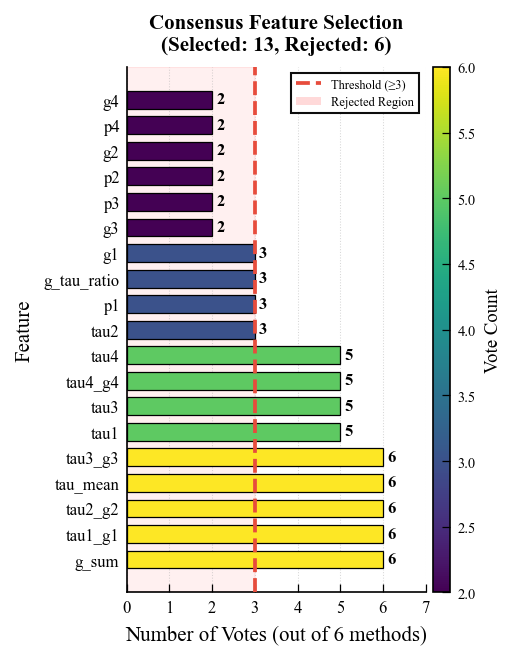


Selected features (>=3 votes): 13
Rejected features (<3 votes): 6


In [7]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

features_list = votes_df.index.tolist()
vote_counts   = votes_df['Total'].tolist()

fig, ax = plt.subplots(figsize=(3.5, 4.5))  

# Color gradient based on vote count using viridis
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=min(vote_counts), vmax=max(vote_counts))
colors = [cmap(norm(v)) for v in vote_counts]

# Shaded region for rejected features (behind bars)
ax.axvspan(0, VOTE_THRESHOLD, alpha=0.06, color='red', zorder=0)

# Horizontal bar plot
bars = ax.barh(features_list, vote_counts, color=colors, edgecolor='black',
               linewidth=0.6, height=0.7, zorder=2)

# Vote count labels
for bar, vote in zip(bars, vote_counts):
    ax.text(vote + 0.1, bar.get_y() + bar.get_height()/2, f'{int(vote)}',
            va='center', ha='left', fontsize=8, fontweight='bold', zorder=3)

# Threshold line
ax.axvline(x=VOTE_THRESHOLD, color='#E74C3C', linestyle='--', linewidth=1.8, zorder=4)

# Axis labels
ax.set_xlabel('Number of Votes (out of 6 methods)', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)

# Title with selected/rejected counts
n_selected = sum(1 for v in vote_counts if v >= VOTE_THRESHOLD)
n_rejected = sum(1 for v in vote_counts if v < VOTE_THRESHOLD)
ax.set_title(f'Consensus Feature Selection\n(Selected: {n_selected}, Rejected: {n_rejected})',
             fontsize=10, fontweight='bold', pad=8)

ax.set_xlim(0, 7)
ax.set_xticks(range(0, 8))

# Clean IEEE styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=8)
ax.xaxis.grid(True, linestyle=':', alpha=0.5, linewidth=0.5)
ax.set_axisbelow(True)

# Legend
legend_elements = [
    Line2D([0], [0], color='#E74C3C', linestyle='--', linewidth=1.8,
           label=f'Threshold (≥{VOTE_THRESHOLD})'),
    Patch(facecolor='red', alpha=0.15, edgecolor='none', label='Rejected Region')
]
ax.legend(handles=legend_elements, fontsize=6, loc='upper right',
          bbox_to_anchor=(1.0, 1.0), frameon=True,
          edgecolor='black', fancybox=False, framealpha=0.95)

# Colorbar (viridis gradient)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, aspect=30)
cbar.set_label('Vote Count', fontsize=9)
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()

# Save PNG + PDF
plt.savefig(os.path.join(RESULTS_FIGS, 'feature_votes_plot.png'),
            dpi=FIGURE_DPI, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(os.path.join(RESULTS_FIGS, 'feature_votes_plot.pdf'),
            format='pdf', bbox_inches='tight', facecolor='white', edgecolor='none')
print("Feature votes plot saved (PNG + PDF)")
plt.show()

# Restore project plot style
apply_plot_style()

print(f"\nSelected features (>={VOTE_THRESHOLD} votes): {n_selected}")
print(f"Rejected features (<{VOTE_THRESHOLD} votes): {n_rejected}")

## 5c. Feature Selection Inside Cross-Validation

To directly address the concern that feature selection was performed *outside*
cross-validation, we repeat the full pipeline — feature selection → scaling → model
fit → evaluation — inside each fold of a 5 × 5 repeated stratified K-fold on the
training set. This ensures that feature selection never sees validation data.

For each of the 25 fold-iterations we record:
- which features were selected (inside the fold-training split only)
- the validation accuracy of a reference model (Random Forest) trained on those features

We then compare the per-fold selected subsets and validation scores against the
original (external) selection to show that the two approaches yield equivalent results.


In [12]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import accuracy_score

N_SPLITS = 5
N_REPEATS = 5
rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS,
                                random_state=RANDOM_STATE)

cv_selections = []      # feature sets selected inside each fold
cv_jaccards = []         # Jaccard vs original external selection
cv_val_scores_inner = [] # validation accuracy with inner-selected features
cv_val_scores_fixed = [] # validation accuracy with original (external) features

print(f"Running {N_SPLITS}×{N_REPEATS} repeated stratified K-fold "
      f"with feature selection INSIDE each fold...")
print(f"(total iterations: {N_SPLITS * N_REPEATS})\n")

for fold_idx, (train_idx, val_idx) in enumerate(rskf.split(X_train, y_train)):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val   = X_train.iloc[val_idx]
    y_fold_val   = y_train.iloc[val_idx]

    # ── Feature selection inside the fold (on fold-train only) ────────
    inner_feats, _ = consensus_feature_selection(X_fold_train, y_fold_train)
    inner_set = set(inner_feats)
    cv_selections.append(inner_set)

    # Jaccard similarity vs. external selection
    inter = len(original_set & inner_set)
    union = len(original_set | inner_set)
    cv_jaccards.append(inter / union if union > 0 else 1.0)

    # ── Train & evaluate with INNER-selected features ────────────────
    scaler_inner = StandardScaler()
    X_ft = scaler_inner.fit_transform(X_fold_train[inner_feats])
    X_fv = scaler_inner.transform(X_fold_val[inner_feats])
    rf = RFC(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_ft, y_fold_train)
    cv_val_scores_inner.append(accuracy_score(y_fold_val, rf.predict(X_fv)))

    # ── Train & evaluate with EXTERNAL (original) selected features ──
    scaler_ext = StandardScaler()
    X_ft2 = scaler_ext.fit_transform(X_fold_train[selected_features])
    X_fv2 = scaler_ext.transform(X_fold_val[selected_features])
    rf2 = RFC(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf2.fit(X_ft2, y_fold_train)
    cv_val_scores_fixed.append(accuracy_score(y_fold_val, rf2.predict(X_fv2)))

    if (fold_idx + 1) % 5 == 0:
        print(f"  Fold {fold_idx + 1}/{N_SPLITS * N_REPEATS} done  "
              f"(inner acc={cv_val_scores_inner[-1]:.4f}, "
              f"external acc={cv_val_scores_fixed[-1]:.4f}, "
              f"Jaccard={cv_jaccards[-1]:.3f})")

# ── Aggregate results ─────────────────────────────────────────────────────
cv_mean_jaccard = np.mean(cv_jaccards)
cv_std_jaccard  = np.std(cv_jaccards)
cv_exact_matches = sum(1 for s in cv_selections if s == original_set)
cv_exact_pct = cv_exact_matches / len(cv_selections) * 100

inner_acc_mean = np.mean(cv_val_scores_inner)
inner_acc_std  = np.std(cv_val_scores_inner)
fixed_acc_mean = np.mean(cv_val_scores_fixed)
fixed_acc_std  = np.std(cv_val_scores_fixed)
acc_diff = abs(inner_acc_mean - fixed_acc_mean) * 100  # in percentage points

# ── Per-feature frequency across CV folds ─────────────────────────────────
cv_freq = pd.Series(0, index=all_features_universe, dtype=int)
for sel in cv_selections:
    for f in sel:
        cv_freq[f] += 1
cv_freq_pct = (cv_freq / len(cv_selections) * 100).sort_values(ascending=False)

cv_summary_rows = []
for feat in all_features_universe:
    cv_summary_rows.append({
        'Feature': feat,
        'In_Original': feat in original_set,
        'CV_Selection_Freq_Pct': cv_freq_pct.get(feat, 0),
    })
cv_summary_df = pd.DataFrame(cv_summary_rows).sort_values(
    'CV_Selection_Freq_Pct', ascending=False)
cv_summary_df.to_csv(os.path.join(RESULTS_TABLES,
    'feature_selection_cv_stability_summary.csv'), index=False)

# ── Save fold-level results ───────────────────────────────────────────────
cv_fold_df = pd.DataFrame({
    'Fold': range(1, len(cv_selections) + 1),
    'Jaccard': cv_jaccards,
    'Inner_Acc': cv_val_scores_inner,
    'External_Acc': cv_val_scores_fixed,
    'N_Features_Inner': [len(s) for s in cv_selections],
})
cv_fold_df.to_csv(os.path.join(RESULTS_TABLES,
    'feature_selection_cv_fold_results.csv'), index=False)

# ── Print report ──────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FEATURE SELECTION INSIDE CV — STABILITY REPORT")
print("=" * 70)
print(f"  CV scheme               : {N_REPEATS}×{N_SPLITS}-fold repeated stratified")
print(f"  Total folds             : {len(cv_selections)}")
print(f"  Original selected feats : {len(original_set)}")
print(f"  Exact-match rate        : {cv_exact_pct:.1f}% ({cv_exact_matches}/{len(cv_selections)})")
print(f"  Mean Jaccard similarity : {cv_mean_jaccard:.4f} ± {cv_std_jaccard:.4f}")
print(f"\n  Validation accuracy (RF, inner selection) : {inner_acc_mean:.4f} ± {inner_acc_std:.4f}")
print(f"  Validation accuracy (RF, external select) : {fixed_acc_mean:.4f} ± {fixed_acc_std:.4f}")
print(f"  Absolute difference                       : {acc_diff:.2f} pp")

if acc_diff < 0.5:
    print(f"\n  >>> Difference < 0.5 pp: external feature selection does NOT inflate results.")
else:
    print(f"\n  >>> Difference ≥ 0.5 pp: consider re-evaluating feature selection strategy.")
print("=" * 70)

print("\nPer-feature selection frequency (inside CV):")
for _, row in cv_summary_df.iterrows():
    marker = "✓" if row['In_Original'] else " "
    print(f"  [{marker}] {row['Feature']:18s}  {row['CV_Selection_Freq_Pct']:5.1f}%")


Running 5×5 repeated stratified K-fold with feature selection INSIDE each fold...
(total iterations: 25)

  Fold 5/25 done  (inner acc=0.9593, external acc=0.9593, Jaccard=1.000)
  Fold 10/25 done  (inner acc=0.9590, external acc=0.9590, Jaccard=1.000)
  Fold 15/25 done  (inner acc=0.9594, external acc=0.9594, Jaccard=1.000)
  Fold 20/25 done  (inner acc=0.9580, external acc=0.9580, Jaccard=1.000)
  Fold 25/25 done  (inner acc=0.9616, external acc=0.9616, Jaccard=1.000)

FEATURE SELECTION INSIDE CV — STABILITY REPORT
  CV scheme               : 5×5-fold repeated stratified
  Total folds             : 25
  Original selected feats : 13
  Exact-match rate        : 100.0% (25/25)
  Mean Jaccard similarity : 1.0000 ± 0.0000

  Validation accuracy (RF, inner selection) : 0.9602 ± 0.0020
  Validation accuracy (RF, external select) : 0.9602 ± 0.0020
  Absolute difference                       : 0.00 pp

  >>> Difference < 0.5 pp: external feature selection does NOT inflate results.

Per-featur

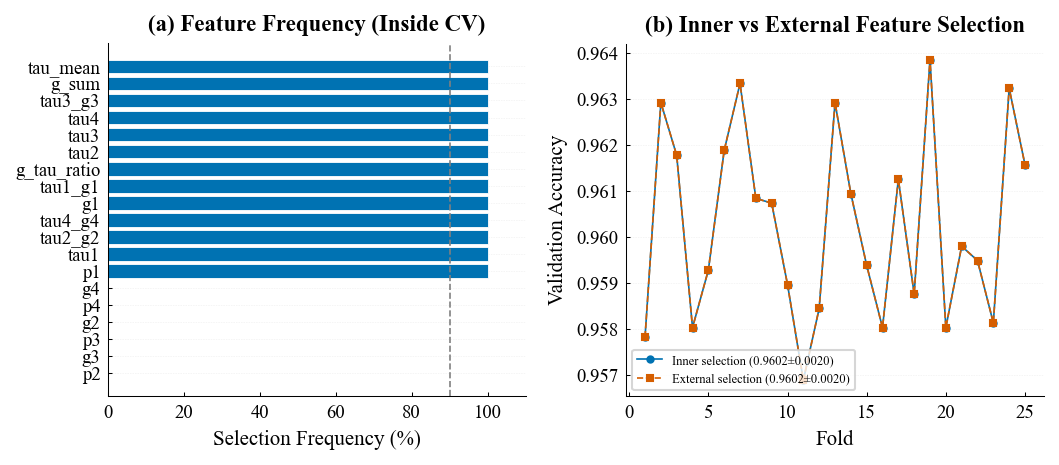

CV comparison plot saved (PNG + PDF)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(IEEE_DOUBLE_COL, 3.2))

# ── Panel (a): Feature frequency comparison ──────────────────────────────
ax = axes[0]
plot_cv = cv_summary_df.sort_values('CV_Selection_Freq_Pct', ascending=True)
bar_colors = [CB_BLUE if f in original_set else CB_RED
              for f in plot_cv['Feature']]
ax.barh(plot_cv['Feature'], plot_cv['CV_Selection_Freq_Pct'],
        color=bar_colors, edgecolor='white', linewidth=0.4)
ax.axvline(x=90, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Selection Frequency (%)')
ax.set_title('(a) Feature Frequency (Inside CV)', fontweight='bold')
ax.set_xlim(0, 110)
clean_ax(ax)

# ── Panel (b): Inner vs External accuracy ────────────────────────────────
ax = axes[1]
fold_nums = range(1, len(cv_selections) + 1)
ax.plot(fold_nums, cv_val_scores_inner, 'o-', color=CB_BLUE, markersize=3,
        linewidth=0.8, label=f'Inner selection ({inner_acc_mean:.4f}±{inner_acc_std:.4f})')
ax.plot(fold_nums, cv_val_scores_fixed, 's--', color=CB_ORANGE, markersize=3,
        linewidth=0.8, label=f'External selection ({fixed_acc_mean:.4f}±{fixed_acc_std:.4f})')
ax.set_xlabel('Fold')
ax.set_ylabel('Validation Accuracy')
ax.set_title('(b) Inner vs External Feature Selection', fontweight='bold')
ax.legend(fontsize=6, loc='lower left', frameon=True)
clean_ax(ax)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIGS, 'feature_selection_cv_comparison.png'),
            dpi=FIGURE_DPI, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(RESULTS_FIGS, 'feature_selection_cv_comparison.pdf'),
            bbox_inches='tight', facecolor='white')
plt.show()
print("CV comparison plot saved (PNG + PDF)")


## 6. Apply Selection and Save Processed Data

The selected features are applied to both training and test sets. Arrays are saved as
`.npy` files for use in downstream notebooks.

In [8]:
X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Save arrays
np.save(os.path.join(RESULTS_TABLES, 'X_train.npy'), X_train_sel.values)
np.save(os.path.join(RESULTS_TABLES, 'X_test.npy'),  X_test_sel.values)
np.save(os.path.join(RESULTS_TABLES, 'y_train.npy'), y_train.values)
np.save(os.path.join(RESULTS_TABLES, 'y_test.npy'),  y_test.values)

# Save feature names alongside arrays
pd.DataFrame({'feature': selected_features}).to_csv(
    os.path.join(RESULTS_TABLES, 'feature_names.csv'), index=False)

print(f"X_train shape: {X_train_sel.shape}")
print(f"X_test  shape: {X_test_sel.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test  shape: {y_test.shape}")


X_train shape: (48000, 13)
X_test  shape: (12000, 13)
y_train shape: (48000,)
y_test  shape: (12000,)


## 7. Post-Selection EDA

EDA on the 13 selected features to verify their distributional properties and
inter-feature relationships before model training.

In [9]:
# Summary statistics
summary = X_train_sel.describe().T
summary['range'] = summary['max'] - summary['min']
summary.to_csv(os.path.join(RESULTS_TABLES, 'feature_summary_selected.csv'))
print("Summary statistics for selected features:")
print(summary[['mean', 'std', 'min', 'max', 'range']].round(4).to_string())


Summary statistics for selected features:
               mean     std     min     max   range
tau1         5.2458  2.7450  0.5008  9.9995  9.4987
tau2         5.2471  2.7400  0.5001  9.9998  9.4997
tau3         5.2434  2.7407  0.5001  9.9998  9.4997
tau4         5.2490  2.7423  0.5001  9.9998  9.4997
p1           3.7465  0.7527  1.5826  5.8644  4.2818
g1           0.5243  0.2745  0.0500  0.9999  0.9499
tau_mean     5.2463  1.3733  0.8764  9.4460  8.5696
g_sum        2.1001  0.5479  0.4777  3.8146  3.3369
tau1_g1      2.7583  2.1775  0.0279  9.9067  9.8787
tau2_g2      2.7639  2.1792  0.0265  9.8856  9.8590
tau3_g3      2.7616  2.1733  0.0265  9.8856  9.8590
tau4_g4      2.7660  2.1800  0.0265  9.8856  9.8590
g_tau_ratio  0.4342  0.1868  0.0724  2.2107  2.1383


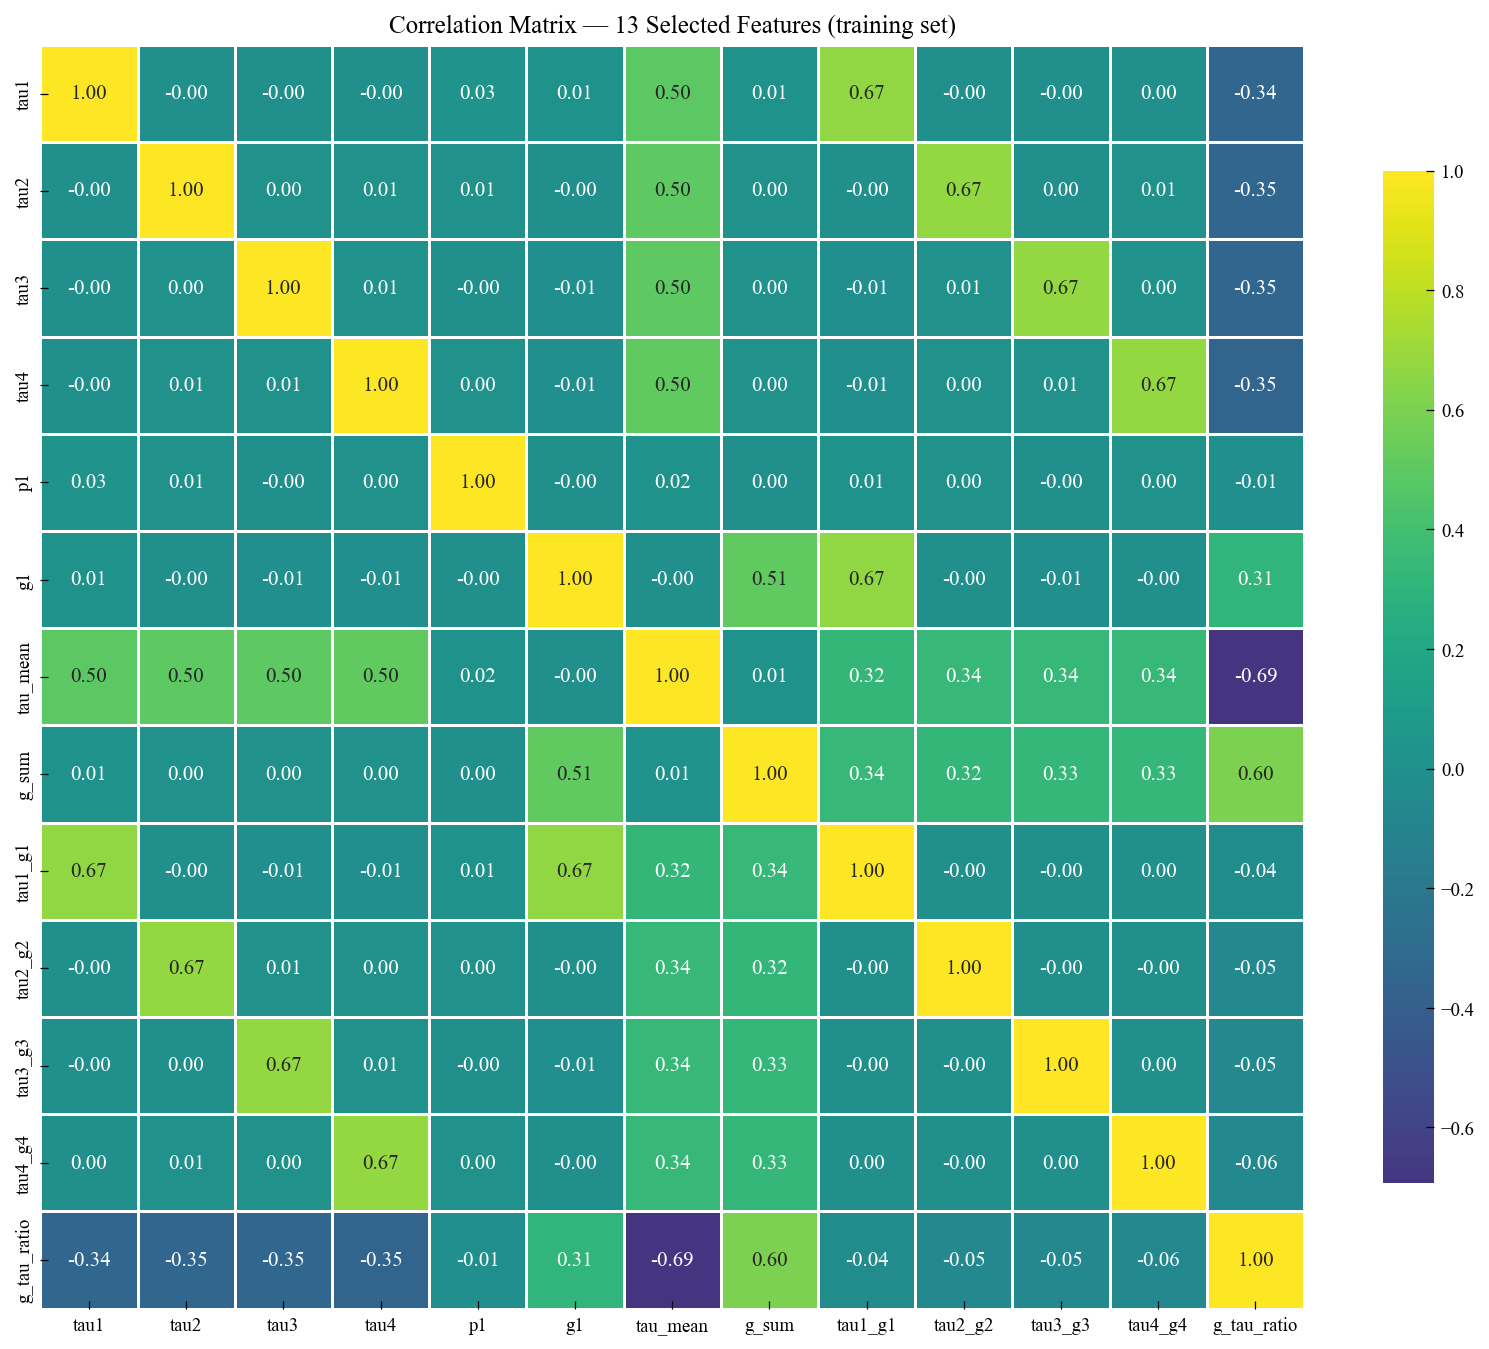

In [ ]:
# Correlation matrix of selected features
corr = X_train_sel.corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — 13 Selected Features (training set)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIGS, 'selected_correlation_matrix.png'), dpi=FIGURE_DPI, bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_FIGS, 'selected_correlation_matrix.pdf'), bbox_inches='tight')
plt.show()


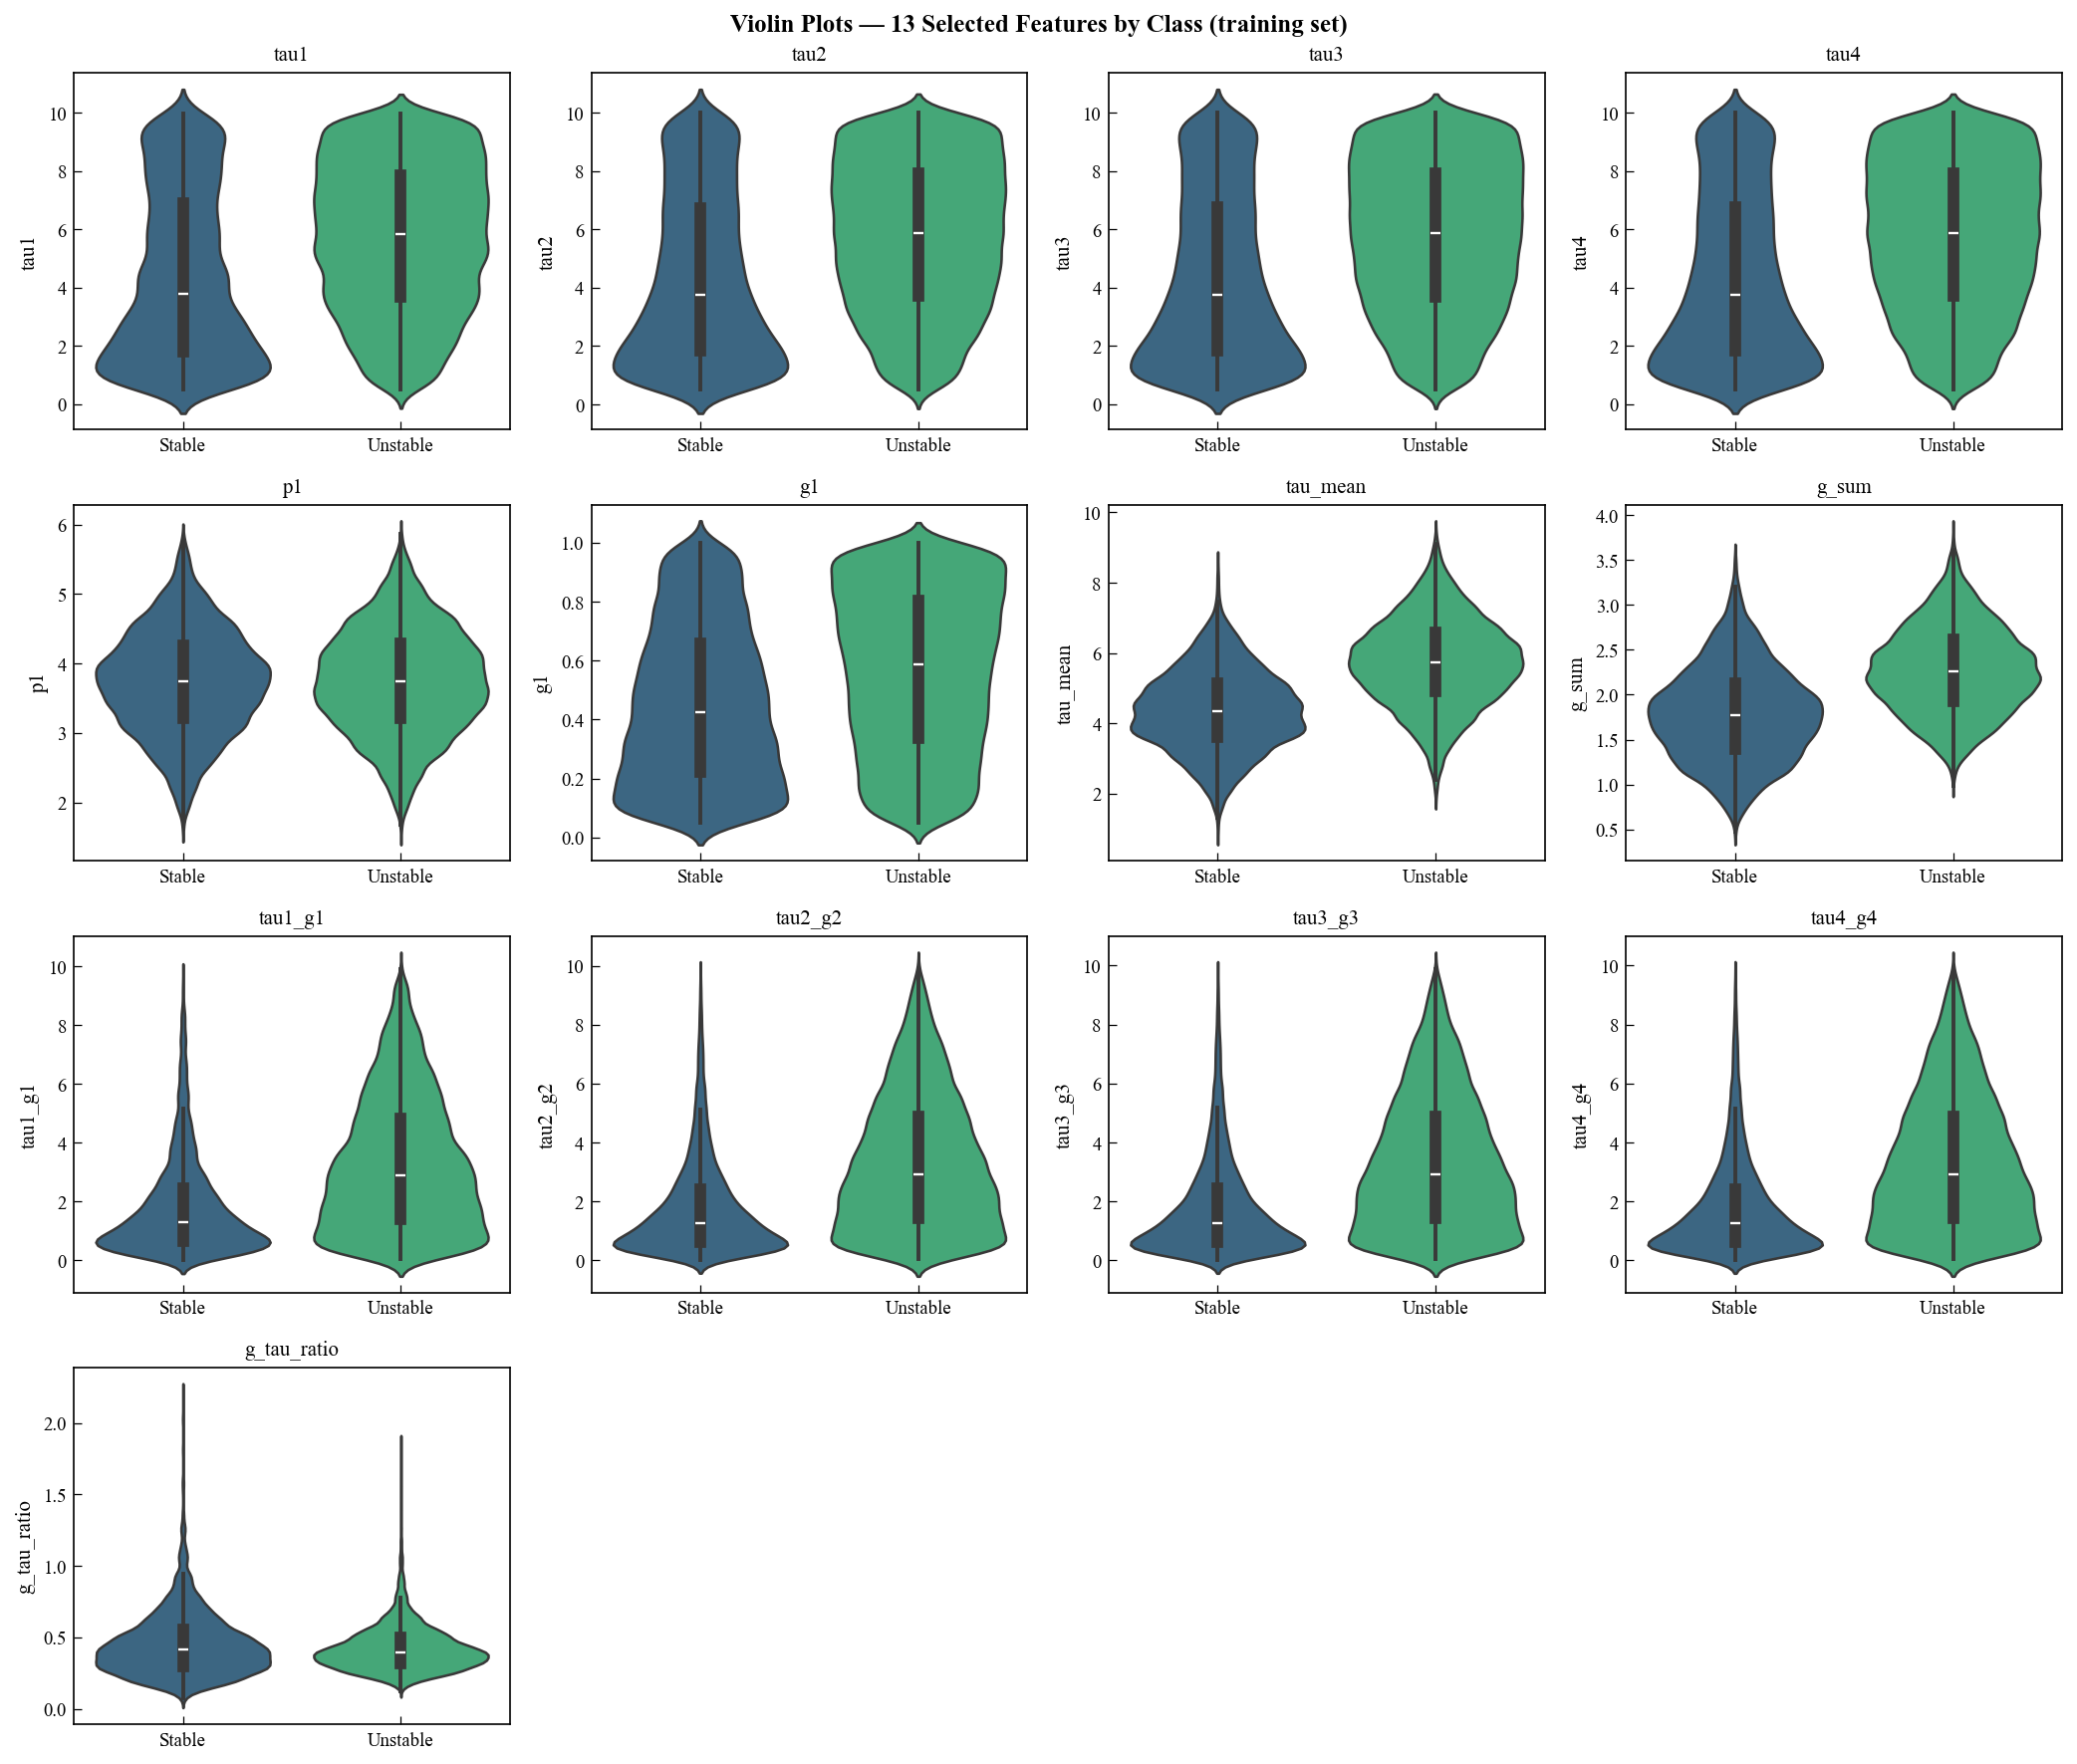

In [12]:
# Violin plots for selected features by class
X_plot = X_train_sel.copy()
X_plot['Class'] = y_train.map({1: 'Unstable', 0: 'Stable'}).values

n_feats = len(selected_features)
ncols = 4
nrows = (n_feats + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for idx, feat in enumerate(selected_features):
    sns.violinplot(data=X_plot, x='Class', y=feat, ax=axes[idx],
                   palette='viridis', hue='Class', legend=False)
    axes[idx].set_title(feat, fontsize=10)
    axes[idx].set_xlabel('')

# Hide unused axes
for idx in range(n_feats, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Violin Plots — 13 Selected Features by Class (training set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIGS, 'selected_violin_plots.png'), dpi=FIGURE_DPI, bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_FIGS, 'selected_violin_plots.pdf'), bbox_inches='tight')
plt.show()


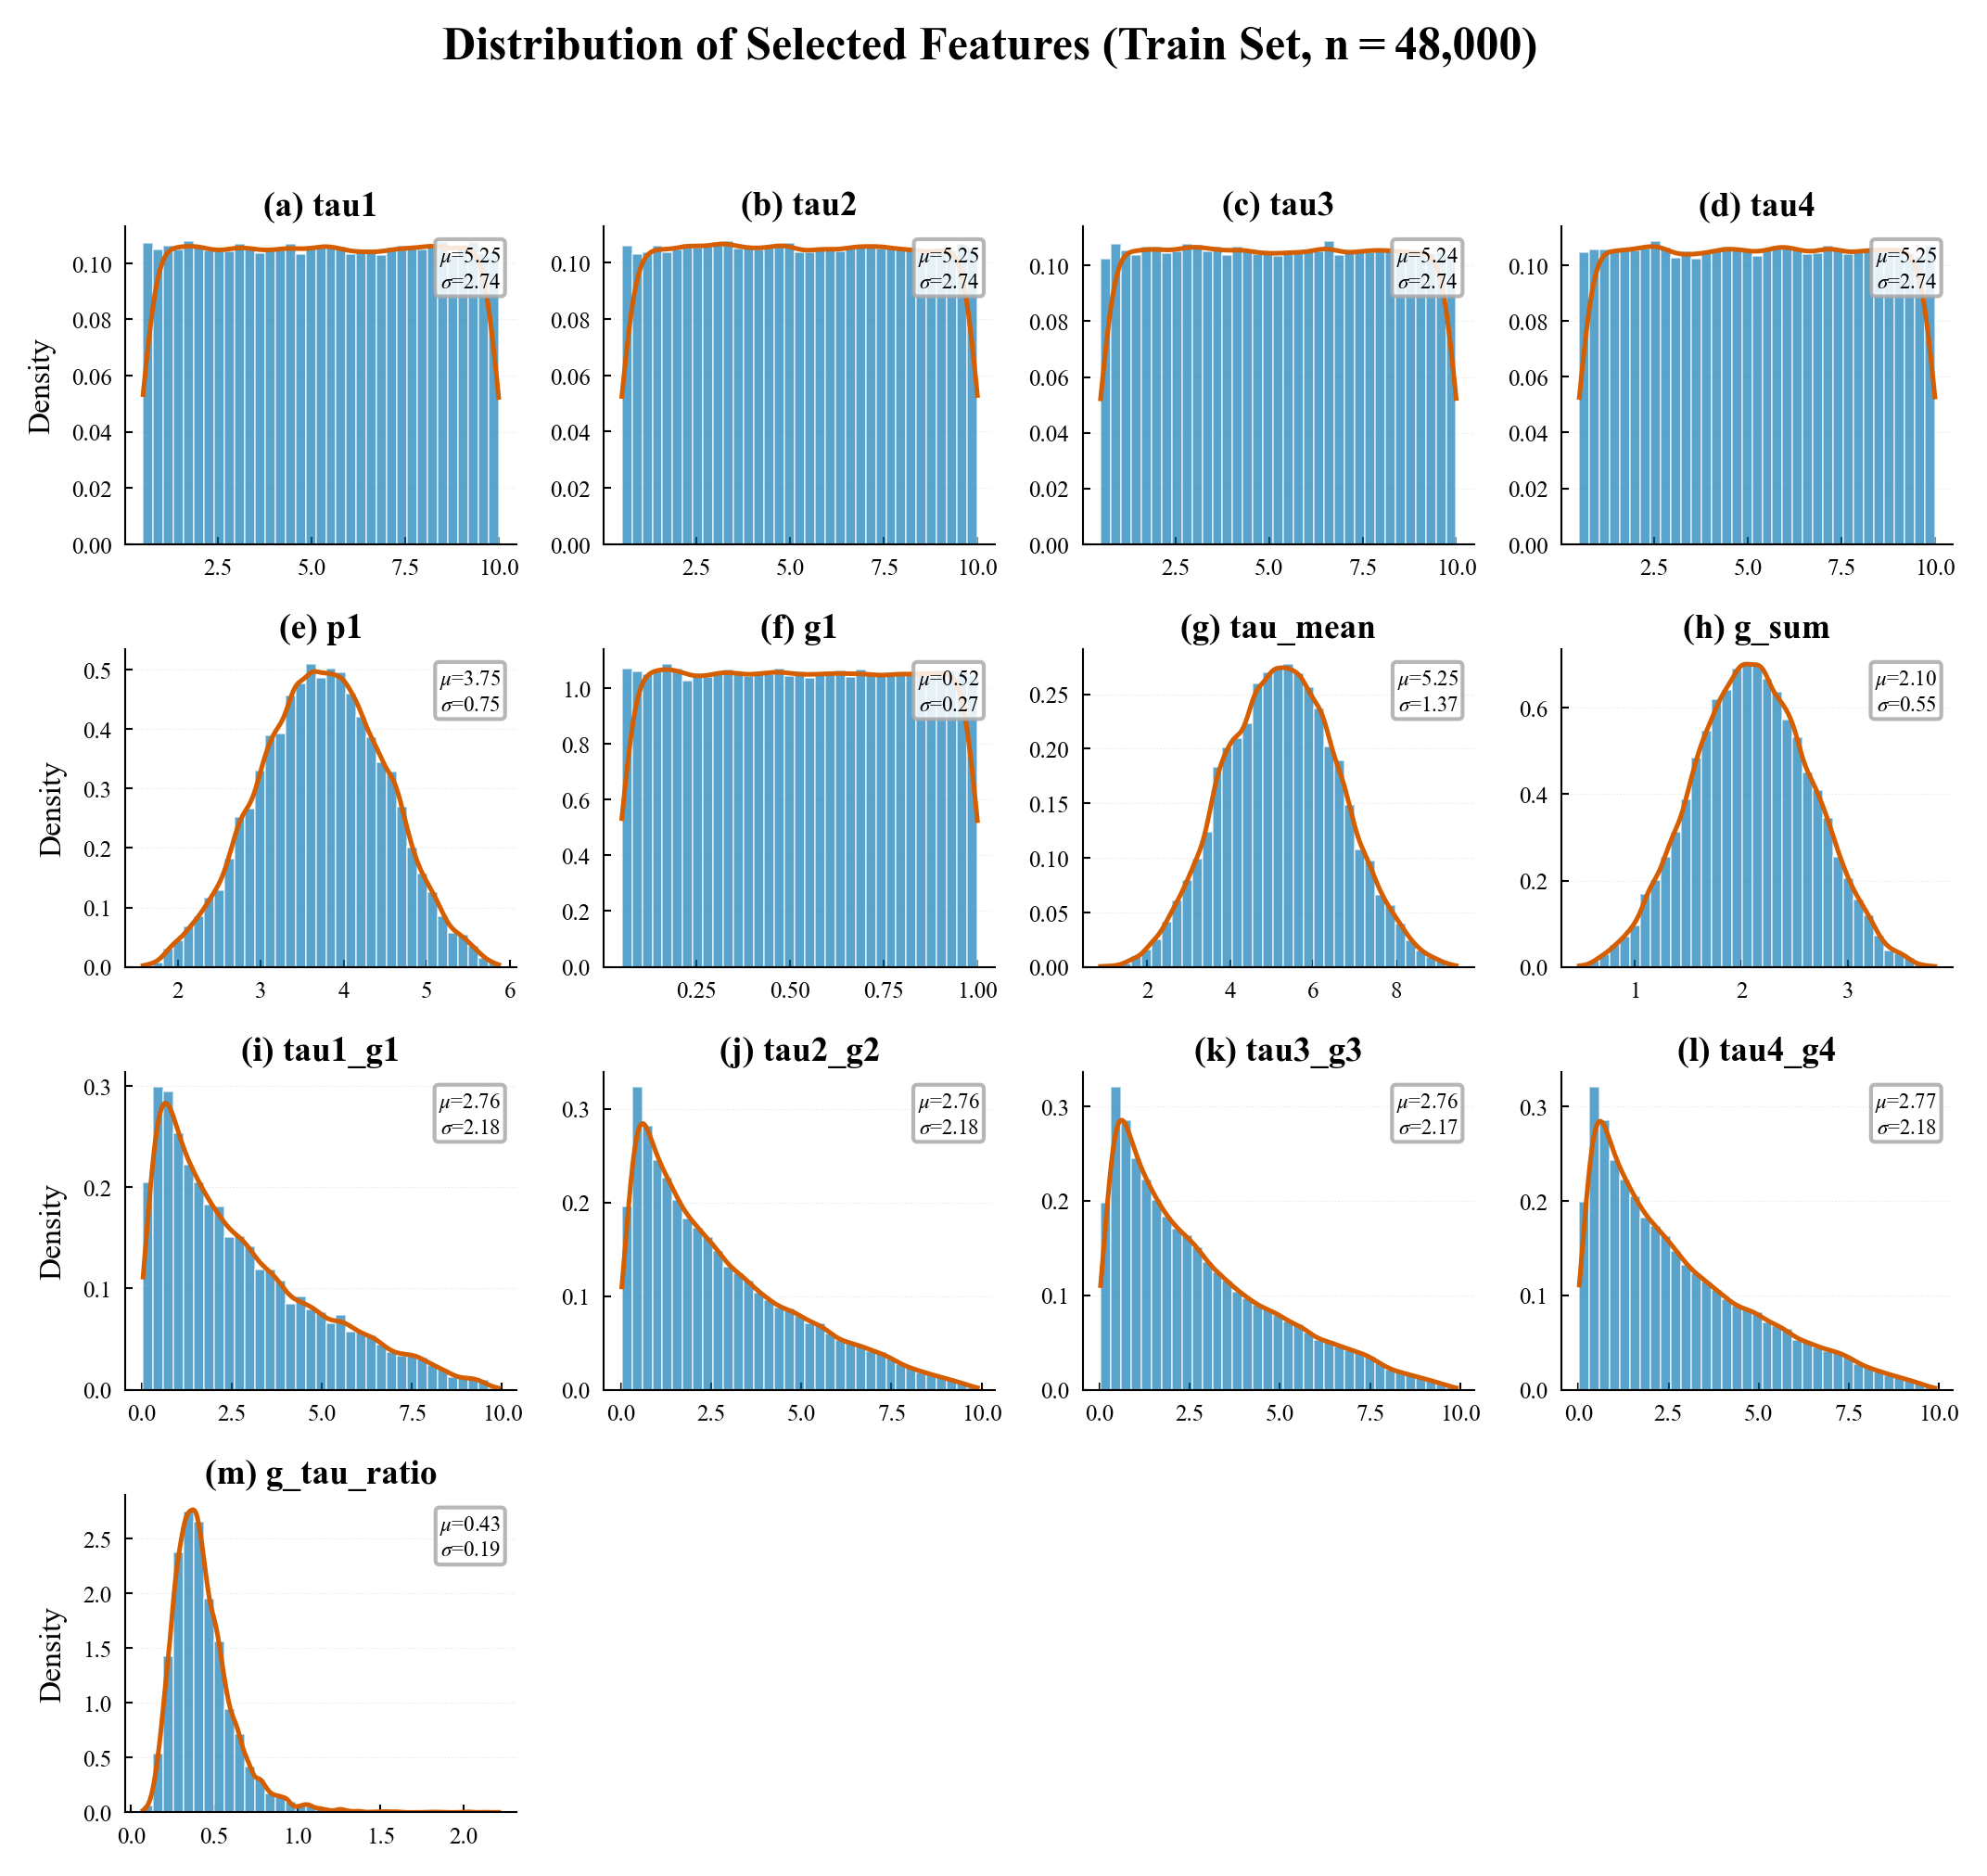

Feature histograms saved (PNG + PDF)


In [9]:
from scipy import stats
from utils.plot_config import apply_dense_plot_style, clean_ax, IEEE_DOUBLE_COL

apply_dense_plot_style()

n_feats = len(selected_features)
ncols = 4
nrows = (n_feats + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(IEEE_DOUBLE_COL, nrows * 1.65))
axes = axes.flatten()

for idx, feature in enumerate(selected_features):
    ax = axes[idx]
    data = X_train_sel[feature]

    # Histogram (density-normalised) + KDE overlay
    ax.hist(data, bins=35, color=CB_BLUE, alpha=0.65,
            edgecolor='white', linewidth=0.4, density=True)

    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color=CB_ORANGE, linewidth=1.2)

    # Sub-figure label + feature name
    ax.set_title(f'({chr(97 + idx)}) {feature}', fontweight='bold', pad=3)
    ax.set_ylabel('Density' if idx % ncols == 0 else '')
    ax.tick_params(axis='both', labelsize=6)

    clean_ax(ax)

    # μ / σ annotation
    ax.text(0.96, 0.94,
            f'$\\mu$={data.mean():.2f}\n$\\sigma$={data.std():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=5.5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='#AAAAAA', alpha=0.85))

# Remove unused subplots
for idx in range(n_feats, len(axes)):
    fig.delaxes(axes[idx])

fig.suptitle(
    f'Distribution of Selected Features (Train Set, n\u2009=\u2009{len(X_train_sel):,})',
    fontweight='bold', y=1.01)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig(os.path.join(RESULTS_FIGS, 'feature_histograms.png'),
            dpi=FIGURE_DPI, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(RESULTS_FIGS, 'feature_histograms.pdf'),
            bbox_inches='tight', facecolor='white')
plt.show()

# Restore default project style
apply_plot_style()
print("Feature histograms saved (PNG + PDF)")


In [13]:
print("Notebook 02 complete.")
print(f"  Selected features : {len(selected_features)}")
print(f"  Training samples  : {X_train_sel.shape[0]}")
print(f"  Test samples      : {X_test_sel.shape[0]}")
print("Ready for Notebook 03: Baseline Evaluation.")


Notebook 02 complete.
  Selected features : 13
  Training samples  : 48000
  Test samples      : 12000
Ready for Notebook 03: Baseline Evaluation.
